# 01 · Loading and plotting each variable

Now we open real data. We'll plot **pressure** and **temperature** *separately*,
at two zoom levels — a single day, and many months.

> 🎯 **What you'll learn in this notebook**
>
> - Load a slice of data with one helper call (no 6 GB read)
> - Understand what a *pandas Series* of measurements looks like
> - See the tide directly in a one-day pressure plot
> - Understand why we *decimate* (down-sample) for long-term views
> - Compare the same variable across all three stations

## The core idea: ask only for what you need

The full dataset is ~6 GB — far too much to load at once. The golden rule of
time-series work is **load a slice**: pick a *station*, a *variable*, and a
*date range*. `oceanlib.load_series(station, variable, start, end)` does exactly
that and hands back a **pandas `Series`** (values indexed by timestamp).

In [1]:
# --- Standard scientific-Python toolkit -----------------------------------
import warnings; warnings.filterwarnings("ignore")  # hide harmless library chatter
import numpy as np                 # arrays & math
import pandas as pd                # labelled time series (our main data type)
import matplotlib.pyplot as plt    # plotting
import matplotlib.dates as mdates  # nice date axes
import oceanlib as ol              # OUR helper module (sits next to this notebook)

# Make every plot a sensible default size with a light grid.
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110})
pd.set_option("display.max_rows", 40)

print("Reading data from:", ol.DATA_DIR)
print("Stations available:", ol.STATIONS)

Reading data from: /Users/quakehunter/Documents/data_exploration/tidal
Stations available: ['AXBA1', 'HYSB1', 'HYS14']


Pick a station to explore. `ol.DEMO` gave us a known-good window for each — we start there. Try changing `STATION` later.

In [2]:
STATION = "AXBA1"          # later: try "HYSB1" or "HYS14"
win = ol.DEMO[STATION]      # a long, gap-free window we pre-found for this station
print(STATION, "demo window:", win)

AXBA1 demo window: {'channel': 'UDO', 'start': '2015-03-09', 'end': '2016-07-11'}


### What does loaded data actually look like?

Let's load one day of pressure and inspect it before plotting. Always look at
your data as *numbers* first — shape, range, sampling — so a weird plot doesn't
surprise you later.

In [3]:
day = pd.Timestamp(win["start"]) + pd.Timedelta(days=30)   # a day inside the window
p = ol.load_series(STATION, "pressure", day, day)

print("type           :", type(p).__name__)
print("number of points:", len(p))
print("time of 1st point:", p.index[0])
print("spacing (seconds):", (p.index[1] - p.index[0]).total_seconds())
print("value range     :", p.min(), "→", p.max())
p.head()

type           : Series
number of points: 5760
time of 1st point: 2015-04-08 00:00:02.270892143
spacing (seconds): 14.999994000000001
value range     : 2654.9506 → 2657.2704


2015-04-08 00:00:02.270892143    2656.7352
2015-04-08 00:00:17.270886421    2656.7332
2015-04-08 00:00:32.270880461    2656.7312
2015-04-08 00:00:47.270874739    2656.7302
2015-04-08 00:01:02.270869017    2656.7296
dtype: float64

> 👀 **What you're seeing**
>
> A `Series`: the left column is the **timestamp** (the index), the right column is the **value**. `oceanlib` has already converted pressure from raw counts to **dbar** (decibars), so AXBA1 reads ~2656 dbar — which, since 1 dbar ≈ 1.02 m of seawater, is just the instrument's depth (~2600 m) plus the tide riding on top. The spacing between timestamps tells you the sample rate.

> 📖 **dbar (decibar)** — the pressure unit we use. Handy because in seawater **1 dbar ≈ 1.02 m of water depth**, so a pressure reading in dbar is essentially the depth in metres, and a pressure *change* in dbar is essentially a sea-level change in metres. (The raw files store integer 'counts'; oceanlib multiplies by 1e-4 dbar/count — a factor verified against the known site depths and the ~0.83 m M2 tide.)

## Short term — one full day at native resolution

saved /Users/quakehunter/Documents/data_exploration/figures/01_AXBA1_oneday.png


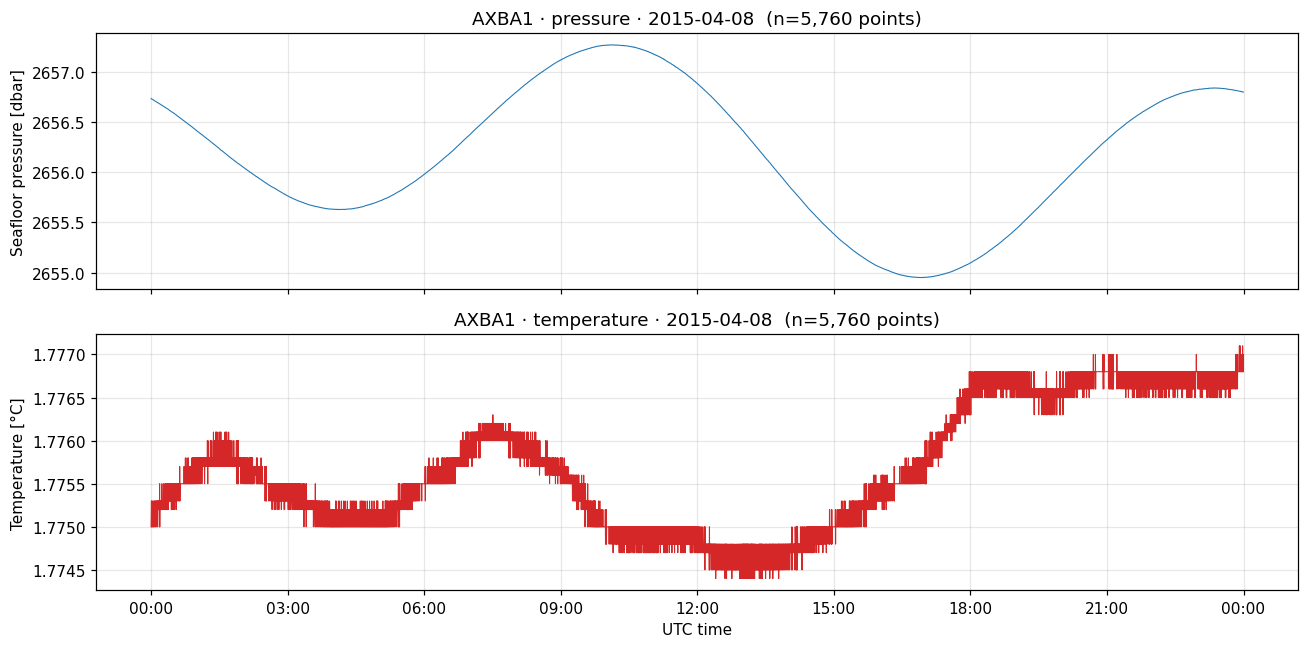

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, var, c in zip(axes, ["pressure", "temperature"], ["C0", "C3"]):
    s = ol.load_series(STATION, var, day, day)        # one variable, one day
    ax.plot(s.index, s.values, c, lw=0.7)
    ax.set_ylabel(ol.label_for(var))                  # auto label + units
    ax.set_title(f"{STATION} · {var} · {day.date()}  (n={len(s):,} points)")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))  # show clock time
axes[-1].set_xlabel("UTC time")
plt.tight_layout(); ol.savefig(fig, f"01_{STATION}_oneday.png"); plt.show()

> 👀 **What you're seeing**
>
> **Top (pressure):** a smooth wave with roughly **two highs and two lows in 24 hours** — that's the tide! This is the *semidiurnal* (twice-daily) tide. **Bottom (temperature):** much flatter — the deep ocean is thermally stable — but you can often spot small wiggles that line up with the tide (water sloshing warmer/colder water past the sensor).

## Long term — months of data, *decimated*

To see seasons and drift we need *months*. But a 9-month span at 1 reading/sec
is ~23 million points — slow to load and impossible to see. The fix is
**decimation**: summarise each hour by its average before plotting.

`oceanlib.load_decimated(..., rule="1h")` resamples *while loading*, so memory
stays tiny.

> 📖 **Decimation / down-sampling** — reducing the number of points by summarising (e.g. one hourly average instead of 3600 one-second readings). It keeps slow features (tides, seasons) while throwing away fast detail you can't see at this zoom anyway.

saved /Users/quakehunter/Documents/data_exploration/figures/01_AXBA1_longterm.png


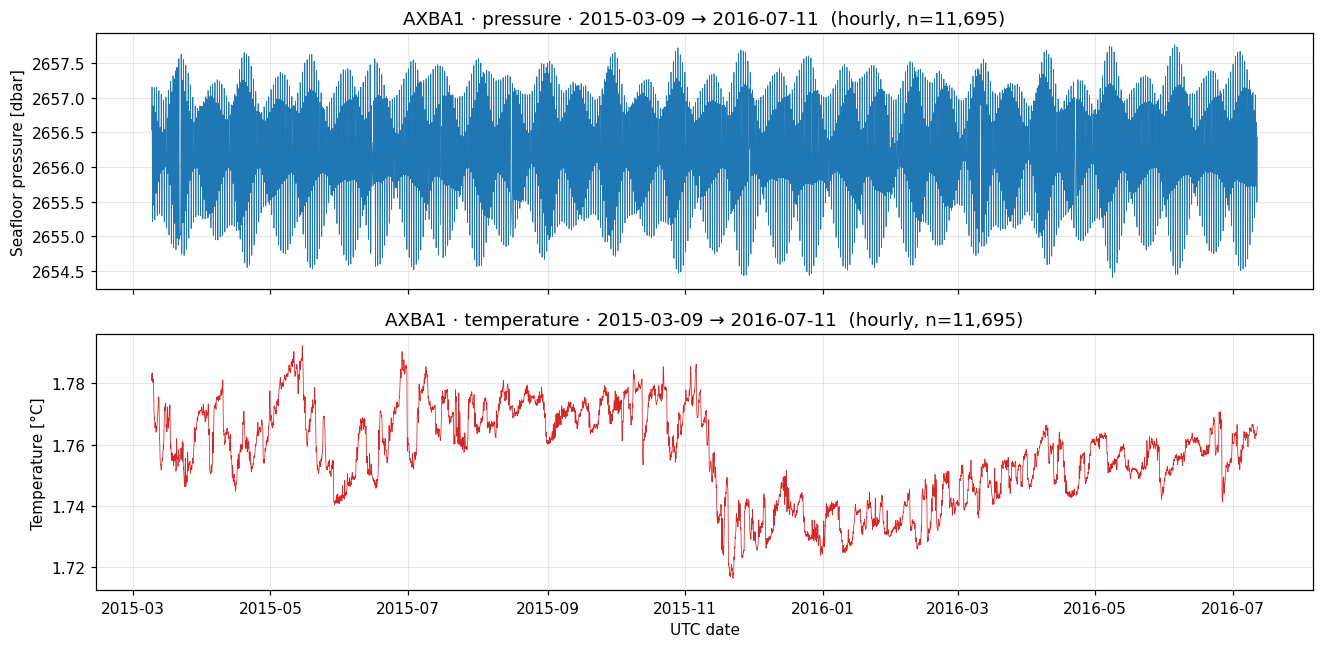

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, var, c in zip(axes, ["pressure", "temperature"], ["C0", "C3"]):
    s = ol.load_decimated(STATION, var, win["start"], win["end"], rule="1h")
    ax.plot(s.index, s.values, c, lw=0.5)
    ax.set_ylabel(ol.label_for(var))
    ax.set_title(f"{STATION} · {var} · {win['start']} → {win['end']}  (hourly, n={len(s):,})")
axes[-1].set_xlabel("UTC date")
plt.tight_layout(); ol.savefig(fig, f"01_{STATION}_longterm.png"); plt.show()

> 👀 **What you're seeing**
>
> Now the individual tides are too fast to see and blur into a thick band — that band's *thickness* is the tidal range. What stands out instead is the **slow drift**: in pressure, a gentle trend (partly the instrument settling, partly real sea-level change); in temperature, a **seasonal swing**. Notebook 04 will mathematically split the fast tide from this slow part.

## Same variable across all three stations

Different stations sit at different depths, so their *absolute* pressure differs
hugely. To compare their *behaviour*, we subtract each one's mean — leaving the
**anomaly** (deviation from average).

> 📖 **Anomaly** — a value with its long-term mean removed, so it wiggles around zero. Lets you overlay signals that otherwise sit at very different baselines.

saved /Users/quakehunter/Documents/data_exploration/figures/01_all_stations_pressure.png


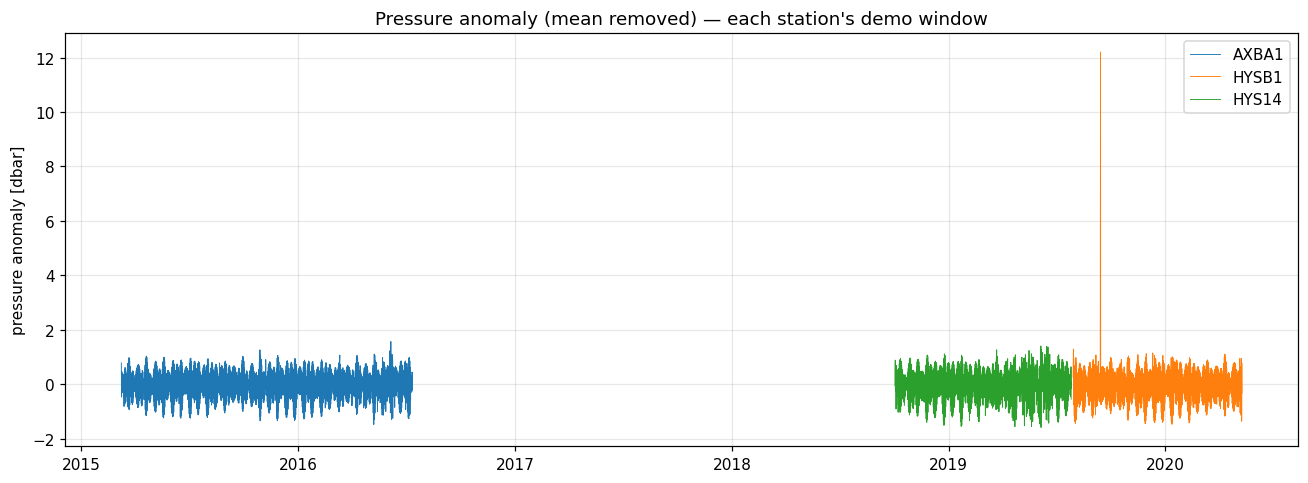

In [6]:
var = "pressure"
fig, ax = plt.subplots(figsize=(12, 4.5))
for sta in ol.STATIONS:
    w = ol.DEMO[sta]
    s = ol.load_decimated(sta, var, w["start"], w["end"], rule="6h")
    ax.plot(s.index, s - s.mean(), lw=0.6, label=sta)   # subtract mean = anomaly
ax.legend(); ax.set_ylabel(f"{var} anomaly [{ol.VARIABLES[var]['units']}]")
ax.set_title("Pressure anomaly (mean removed) — each station's demo window")
plt.tight_layout(); ol.savefig(fig, "01_all_stations_pressure.png"); plt.show()

> 👀 **What you're seeing**
>
> The windows differ per station, so they don't line up in time — that's expected. The point is the *character*: all show the same thick tidal band plus slow drift, confirming the physics is consistent across sites.

> ✏️ **Try it yourself**
>
> 1. Set `STATION = 'HYS14'` at the top and re-run. How does its one-day tide differ?
> 2. In the one-day plot, change `day` to a date 5 months later and look for gaps.
> 3. Re-run the long-term plot with `rule='1D'` (daily averages). What disappears, what remains?
> 4. Plot temperature anomaly across stations by changing `var = 'temperature'`.

> ✅ **Recap**
>
> You can load any station/variable/date slice, inspect it as numbers, and plot it short-term (native rate — tides visible) and long-term (decimated — drift & seasons visible). You met *dbar* (pressure units, ≈ metres of sea level), *decimation*, and *anomaly*.
>
> ➡️ **Next:** `02_signals_together.ipynb` — overlay pressure and temperature to compare them.